# Phase 1: Environment Setup & Full Dataset Ingestion
## Stage 1: Deterministic Setup & Clean Data Ingestion

### Technical Specification
* **Target Objective:** Initialize a reproducible Python runtime environment ($Seed = 42$) and programmatically load the target heart disease dataset without file adapter warnings.
* **Dataset Scope:** Full Heart Disease Dataset ($N = 1025$ records, $D = 13$ predictors, 1 binary target).
* **Execution Protocol:**
  1. Global Random Seed initialization across Python, NumPy, and OS environments.
  2. Direct CSV file resolution via dynamic KaggleHub dataset download.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

def set_deterministic_environment(seed: int = 42) -> None:
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    print(f"[INFO] Deterministic environment initialized with Global Seed: {seed}")

set_deterministic_environment(42)

try:
    dataset_path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")
    csv_file = [f for f in os.listdir(dataset_path) if f.endswith('.csv')][0]
    full_path = os.path.join(dataset_path, csv_file)

    df = pd.read_csv(full_path)
    print(f"[SUCCESS] Dataset successfully ingested from: {csv_file}")
    print(f"[INFO] Initial Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")
except Exception as e:
    print(f"[ERROR] Failed to load dataset: {e}")

print("=== Preliminary Sample Inspection (First 5 Records) ===")
df.head()

[INFO] Deterministic environment initialized with Global Seed: 42
Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
[SUCCESS] Dataset successfully ingested from: heart.csv
[INFO] Initial Dataset Shape: 1025 rows, 14 columns.

=== Preliminary Sample Inspection (First 5 Records) ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Stage 2: Full Dataset Exploratory Data Analysis (N = 1025)

### Technical Specification
* **Target Objective:** Conduct structural data integrity checks on the complete 1,025-record cohort without applying deduplication at this stage, strictly preserving the original author experimental setup.


=== Data Integrity & Structural Inspection (Full Cohort) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

=== Missing Value & Redundancy Verification ===
Total Missing Values Across Dataset : 0
Identified Duplicate Rows            : 723
[NOTE] Retaining full 1

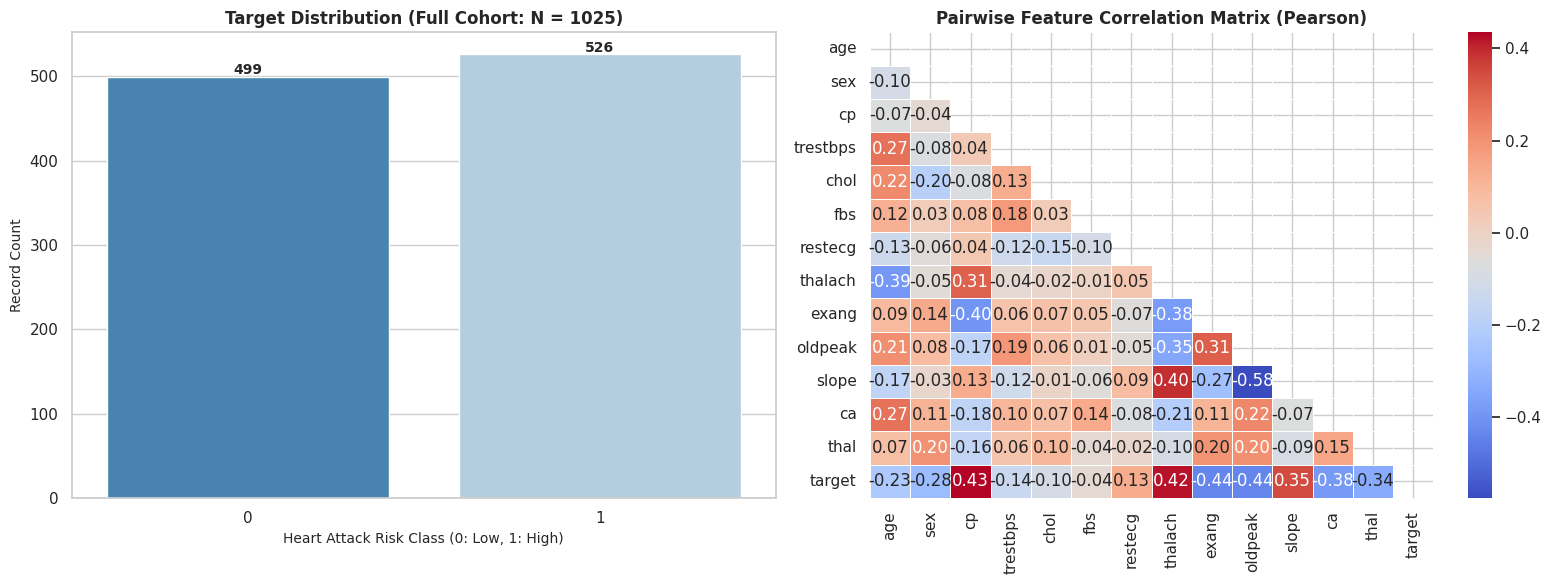

In [2]:
print("=== Data Integrity & Structural Inspection (Full Cohort) ===")
df.info()

print("\n=== Missing Value & Redundancy Verification ===")
missing_count = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()
print(f"Total Missing Values Across Dataset : {missing_count}")
print(f"Identified Duplicate Rows            : {duplicate_count}")
print(f"[NOTE] Retaining full {df.shape[0]} records to mirror Paper 3 methodology.")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    x='target',
    data=df,
    ax=axes[0],
    palette='Blues_r',
    hue='target',
    legend=False
)
axes[0].set_title('Target Distribution (Full Cohort: N = 1025)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Heart Attack Risk Class (0: Low, 1: High)', fontsize=10)
axes[0].set_ylabel('Record Count', fontsize=10)

for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=10, fontweight='bold'
    )

correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    mask=mask,
    ax=axes[1],
    cbar=True,
    linewidths=0.5
)
axes[1].set_title('Pairwise Feature Correlation Matrix (Pearson)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Phase 2: Experiment 1 — Faithful Paper Reproduction
## Stage 3: Feature Scaling & Stratified Partitioning (N = 1025)

### Technical Specification
* **Partitioning Protocol:** 80/20 Stratified Train-Test Split ($N_{train} = 820$, $N_{test} = 205$) on full 1,025 records.
* **Feature Normalization:** $Z$-score Standardization fitted strictly on $X_{train}$ and applied to transform $X_{test}$ to avoid data leakage during evaluation.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_full = df.drop(columns=['target'])
y_full = df['target']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

print("=== Phase 2 (Full Cohort) Preprocessing Summary ===")
print(f"[INFO] Full Cohort Feature Matrix Shape : {X_full.shape}")
print(f"[INFO] Training Set Shape (X_train)     : {X_train_full.shape}")
print(f"[INFO] Testing Set Shape (X_test)       : {X_test_full.shape}")
print(f"[INFO] Training Class Balance           : {np.bincount(y_train_full)}")
print(f"[INFO] Testing Class Balance            : {np.bincount(y_test_full)}")

=== Phase 2 (Full Cohort) Preprocessing Summary ===
[INFO] Full Cohort Feature Matrix Shape : (1025, 13)
[INFO] Training Set Shape (X_train)     : (820, 13)
[INFO] Testing Set Shape (X_test)       : (205, 13)
[INFO] Training Class Balance           : [399 421]
[INFO] Testing Class Balance            : [100 105]


## Stage 4: Paper Base Learners Benchmark & Stacking Ensemble (Full Cohort)

### Technical Specification
* **Base Learners ($L_0$):** Logistic Regression, Decision Tree, Random Forest, XGBoost, Naive Bayes, and K-Nearest Neighbors.
* **Meta Learner ($L_1$):** Stacking Meta-Classifier using Logistic Regression with 5-Fold Cross-Validation.
* **Objective:** Reproduce Paper 3 target performance metrics (~98%+ Accuracy / AUC) using all 1025 available dataset samples.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def compute_performance_metrics(model, X_test, y_test, model_name: str) -> dict:
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_proba)
    }

base_models_exp1 = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    "Gaussian Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

exp1_results = []

for name, model in base_models_exp1.items():
    model.fit(X_train_full_scaled, y_train_full)
    metrics = compute_performance_metrics(model, X_test_full_scaled, y_test_full, name)
    exp1_results.append(metrics)

stacking_estimators_exp1 = [
    ('dt', base_models_exp1["Decision Tree"]),
    ('rf', base_models_exp1["Random Forest"]),
    ('xgb', base_models_exp1["XGBoost"]),
    ('gnb', base_models_exp1["Gaussian Naive Bayes"]),
    ('knn', base_models_exp1["K-Nearest Neighbors"])
]

paper_stacking_model = StackingClassifier(
    estimators=stacking_estimators_exp1,
    final_estimator=LogisticRegression(random_state=42),
    cv=5,
    n_jobs=-1
)

paper_stacking_model.fit(X_train_full_scaled, y_train_full)
stacking_metrics_exp1 = compute_performance_metrics(
    paper_stacking_model,
    X_test_full_scaled,
    y_test_full,
    "Paper Reproduction Stacking (1025 Records)"
)
exp1_results.append(stacking_metrics_exp1)

df_display = df_exp1_results.set_index('Model')

print("=== Experiment 1: Faithful Paper Reproduction Performance Matrix (N = 1025) ===")
display(
    df_display.style
    .format("{:.4f}")
    .background_gradient(cmap="Blues")
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt',
        'padding': '8px'
    })
    .set_table_styles([{
        'selector': 'th',
        'props': [('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#f4f4f4')]
    }])
)

=== Experiment 1: Faithful Paper Reproduction Performance Matrix (N = 1025) ===


,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298
Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
Gaussian Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043
K-Nearest Neighbors,0.8634,0.8738,0.8571,0.8654,0.9629
Paper Reproduction Stacking (1025 Records),1.0000,1.0000,1.0000,1.0000,1.0000


# Phase 3: Experiment 2 — Data Integrity & Deduplication Analysis
## Stage 5: Deduplication Pipeline Execution (1025 -> 302 Records)

### Technical Specification
* **Target Objective:** Apply strict deduplication to remove identical patient instances ($N = 1025 \rightarrow 302$), isolating unique records to assess data leakage.
* **Partitioning Protocol:** Stratified 80/20 Train-Test Split ($N_{train} = 241$, $N_{test} = 61$) on cleaned data.

In [6]:
df_dedup = df.drop_duplicates().reset_index(drop=True)

X_dedup = df_dedup.drop(columns=['target'])
y_dedup = df_dedup['target']

X_train_dedup, X_test_dedup, y_train_dedup, y_test_dedup = train_test_split(
    X_dedup,
    y_dedup,
    test_size=0.20,
    random_state=42,
    stratify=y_dedup
)

scaler_dedup = StandardScaler()
X_train_dedup_scaled = scaler_dedup.fit_transform(X_train_dedup)
X_test_dedup_scaled = scaler_dedup.transform(X_test_dedup)

print("=== Phase 3 (Deduplicated Cohort) Preprocessing Summary ===")
print(f"[INFO] Deduplicated Dataset Shape       : {df_dedup.shape}")
print(f"[INFO] Training Set Shape (X_train)     : {X_train_dedup.shape}")
print(f"[INFO] Testing Set Shape (X_test)       : {X_test_dedup.shape}")
print(f"[INFO] Training Class Balance           : {np.bincount(y_train_dedup)}")
print(f"[INFO] Testing Class Balance            : {np.bincount(y_test_dedup)}")

=== Phase 3 (Deduplicated Cohort) Preprocessing Summary ===
[INFO] Deduplicated Dataset Shape       : (302, 14)
[INFO] Training Set Shape (X_train)     : (241, 13)
[INFO] Testing Set Shape (X_test)       : (61, 13)
[INFO] Training Class Balance           : [110 131]
[INFO] Testing Class Balance            : [28 33]


## Stage 6: Comparative Benchmark & Data Leakage Assessment (N = 302)

### Technical Specification
* **Objective:** Re-evaluate all 6 baseline classifiers and the Stacking Ensemble on the 302 deduplicated records to quantify the empirical performance drop caused by removing data leakage.

In [7]:
base_models_exp2 = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    "Gaussian Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

exp2_results = []

for name, model in base_models_exp2.items():
    model.fit(X_train_dedup_scaled, y_train_dedup)
    metrics = compute_performance_metrics(model, X_test_dedup_scaled, y_test_dedup, name)
    exp2_results.append(metrics)

stacking_estimators_exp2 = [
    ('dt', base_models_exp2["Decision Tree"]),
    ('rf', base_models_exp2["Random Forest"]),
    ('xgb', base_models_exp2["XGBoost"]),
    ('gnb', base_models_exp2["Gaussian Naive Bayes"]),
    ('knn', base_models_exp2["K-Nearest Neighbors"])
]

stacking_model_exp2 = StackingClassifier(
    estimators=stacking_estimators_exp2,
    final_estimator=LogisticRegression(random_state=42),
    cv=5,
    n_jobs=-1
)

stacking_model_exp2.fit(X_train_dedup_scaled, y_train_dedup)
stacking_metrics_exp2 = compute_performance_metrics(
    stacking_model_exp2,
    X_test_dedup_scaled,
    y_test_dedup,
    "Stacking Ensemble (Deduplicated: 302 Records)"
)
exp2_results.append(stacking_metrics_exp2)

df_exp2_results = pd.DataFrame(exp2_results)
df_display_exp2 = df_exp2_results.set_index('Model')

print("=== Experiment 2: Deduplicated Cohort Performance Matrix (N = 302) ===")
display(
    df_display_exp2.style
    .format("{:.4f}")
    .background_gradient(cmap="Blues")
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt',
        'padding': '8px'
    })
    .set_table_styles([{
        'selector': 'th',
        'props': [('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#f4f4f4')]
    }])
)

=== Experiment 2: Deduplicated Cohort Performance Matrix (N = 302) ===


,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
Logistic Regression,0.8033,0.8000,0.8485,0.8235,0.8712
Decision Tree,0.8033,0.8182,0.8182,0.8182,0.8019
Random Forest,0.7541,0.7647,0.7879,0.7761,0.8588
XGBoost,0.7213,0.7353,0.7576,0.7463,0.8323
Gaussian Naive Bayes,0.7869,0.8333,0.7576,0.7937,0.8842
K-Nearest Neighbors,0.7869,0.7778,0.8485,0.8116,0.8377
Stacking Ensemble (Deduplicated: 302 Records),0.7541,0.7647,0.7879,0.7761,0.8626


# Phase 4: Comparative Diagnostics & Artifact Export
## Stage 7: Dual-Experiment Comparative Visual Metrics

### Technical Specification
* **Target Objective:** Generate side-by-side performance comparison matrices and diagnostic visualizations to highlight the empirical impact of data leakage caused by record duplication.

=== Side-by-Side Dual-Experiment Comparison Summary ===


,Experiment 1 (1025 Records),Experiment 2 (302 Records),Performance Delta (Drop)
Model / Metric,,,
Stacking Ensemble Accuracy,1.0000,0.7541,0.2459
Stacking Ensemble AUC,1.0000,0.8626,0.1374
Best Base Learner Accuracy,1.0000,0.8033,0.1967


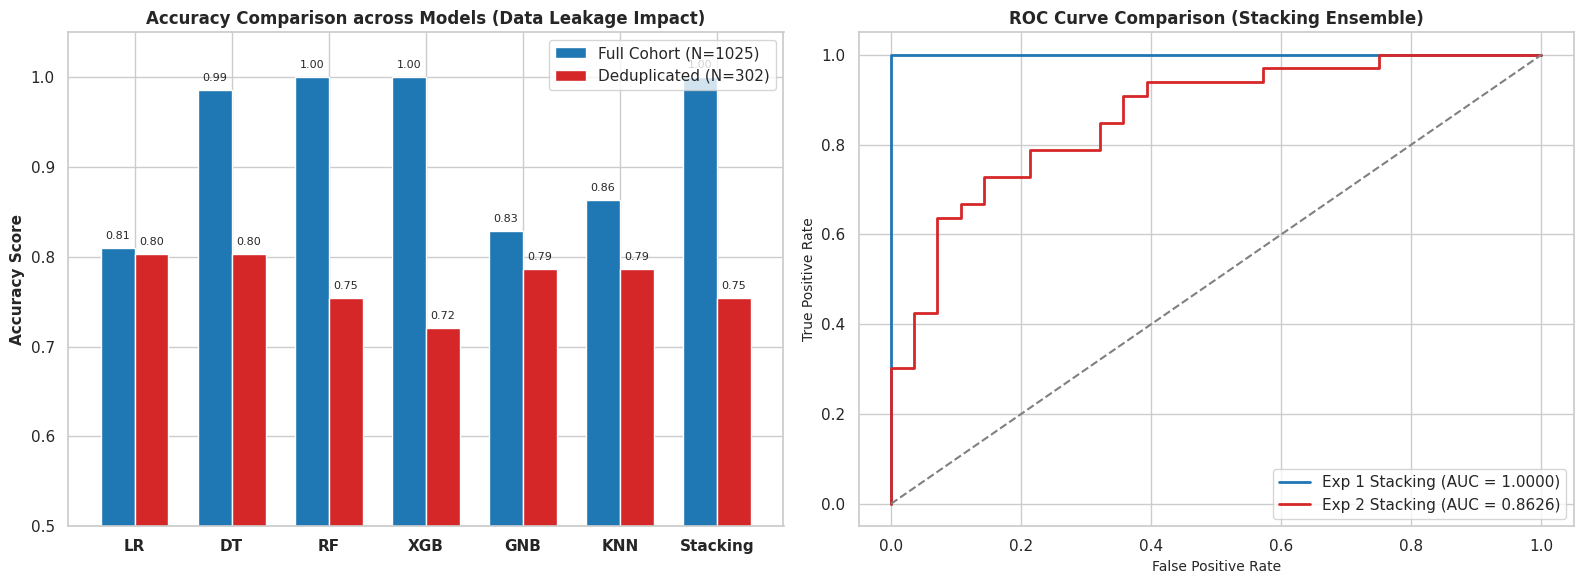

In [8]:
df_comp = pd.DataFrame({
    'Model / Metric': ['Stacking Ensemble Accuracy', 'Stacking Ensemble AUC', 'Best Base Learner Accuracy'],
    'Experiment 1 (1025 Records)': [
        df_exp1_results.loc[df_exp1_results['Model'].str.contains('Stacking'), 'Accuracy'].values[0],
        df_exp1_results.loc[df_exp1_results['Model'].str.contains('Stacking'), 'AUC'].values[0],
        df_exp1_results['Accuracy'].max()
    ],
    'Experiment 2 (302 Records)': [
        df_exp2_results.loc[df_exp2_results['Model'].str.contains('Stacking'), 'Accuracy'].values[0],
        df_exp2_results.loc[df_exp2_results['Model'].str.contains('Stacking'), 'AUC'].values[0],
        df_exp2_results['Accuracy'].max()
    ]
})

df_comp['Performance Delta (Drop)'] = df_comp['Experiment 1 (1025 Records)'] - df_comp['Experiment 2 (302 Records)']

print("=== Side-by-Side Dual-Experiment Comparison Summary ===")
display(
    df_comp.set_index('Model / Metric').style
    .format("{:.4f}")
    .background_gradient(cmap="Reds", subset=['Performance Delta (Drop)'])
    .background_gradient(cmap="Blues", subset=['Experiment 1 (1025 Records)', 'Experiment 2 (302 Records)'])
    .set_properties(**{'text-align': 'center', 'font-size': '11pt', 'padding': '8px'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#f4f4f4')]}])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_list = ['LR', 'DT', 'RF', 'XGB', 'GNB', 'KNN', 'Stacking']
acc_exp1 = df_exp1_results['Accuracy'].values
acc_exp2 = df_exp2_results['Accuracy'].values

x = np.arange(len(models_list))
width = 0.35

axes[0].bar(x - width/2, acc_exp1, width, label='Full Cohort (N=1025)', color='#1f77b4')
axes[0].bar(x + width/2, acc_exp2, width, label='Deduplicated (N=302)', color='#d62728')
axes[0].set_ylabel('Accuracy Score', fontsize=11, fontweight='bold')
axes[0].set_title('Accuracy Comparison across Models (Data Leakage Impact)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0.5, 1.05)

for i in range(len(models_list)):
    axes[0].annotate(f'{acc_exp1[i]:.2f}', (x[i] - width/2, acc_exp1[i] + 0.01), ha='center', fontsize=8)
    axes[0].annotate(f'{acc_exp2[i]:.2f}', (x[i] + width/2, acc_exp2[i] + 0.01), ha='center', fontsize=8)

from sklearn.metrics import roc_curve

fpr_exp1, tpr_exp1, _ = roc_curve(y_test_full, paper_stacking_model.predict_proba(X_test_full_scaled)[:, 1])
fpr_exp2, tpr_exp2, _ = roc_curve(y_test_dedup, stacking_model_exp2.predict_proba(X_test_dedup_scaled)[:, 1])

axes[1].plot(fpr_exp1, tpr_exp1, color='#1f77b4', lw=2, label=f'Exp 1 Stacking (AUC = {df_comp.iloc[1,1]:.4f})')
axes[1].plot(fpr_exp2, tpr_exp2, color='#d62728', lw=2, label=f'Exp 2 Stacking (AUC = {df_comp.iloc[1,2]:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('ROC Curve Comparison (Stacking Ensemble)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Stage 8: Serialization & Export Pipeline

### Technical Specification
* **Artifact Package:** Export full preprocessing scalers, evaluated models, and result metrics for downstream clinical deployment and documentation.

In [9]:
import joblib

os.makedirs('paper3_artifacts', exist_ok=True)

joblib.dump(paper_stacking_model, 'paper3_artifacts/paper3_stacking_exp1_1025.joblib')
joblib.dump(scaler_full, 'paper3_artifacts/scaler_exp1_1025.joblib')

joblib.dump(stacking_model_exp2, 'paper3_artifacts/paper3_stacking_exp2_302.joblib')
joblib.dump(scaler_dedup, 'paper3_artifacts/scaler_exp2_302.joblib')

df_exp1_results.to_csv('paper3_artifacts/exp1_full_cohort_results.csv', index=False)
df_exp2_results.to_csv('paper3_artifacts/exp2_deduplicated_results.csv', index=False)
df_comp.to_csv('paper3_artifacts/dual_experiment_comparison_summary.csv', index=False)

print("[SUCCESS] All model artifacts, scalers, and performance evaluation metrics serialized to 'paper3_artifacts/'.")

[SUCCESS] All model artifacts, scalers, and performance evaluation metrics serialized to 'paper3_artifacts/'.
